In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix_diabetic import DataProcessor as DP
from data.splitter import SurvivalSplitter
from data.RFMFeatures_diabetic import RFMFeatures
from models.cox_model_upd_diabetic import CoxModelUpd
from models.rsf_model import RSFModel
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.evaluator import SurvivalEvaluator
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('data/diabetic_data_1.csv')
df.info()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              47021 non-null  int64  
 1   patient_nbr               47021 non-null  int64  
 2   race                      47021 non-null  object 
 3   gender                    47021 non-null  object 
 4   age                       47021 non-null  object 
 5   weight                    47021 non-null  object 
 6   admission_type_id         47021 non-null  int64  
 7   discharge_disposition_id  47021 non-null  int64  
 8   admission_source_id       47021 non-null  int64  
 9   time_in_hospital          47021 non-null  int64  
 10  payer_code                47021 non-null  object 
 11  medical_specialty         47021 non-null  object 
 12  num_lab_procedures        47021 non-null  int64  
 13  num_procedures            47021 non-null  int64  
 14  num_me

In [3]:
processor = DP("data/diabetic_data_1.csv")
cox_df = processor.load_and_prepare()

cox_df['race'] = cox_df['race'].str.strip('').str.upper()
cox_df['gender'] = cox_df['gender'].str.strip().str.upper()
sex_mapping = {
    'MALE': 0,
    'FEMALE': 1
}
cox_df['gender'] = cox_df['gender'].map(sex_mapping)

cox_df.head()
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                47021 non-null  int64  
 1   episode_col               47021 non-null  int64  
 2   start                     47021 non-null  float64
 3   stop                      47021 non-null  float64
 4   event                     47021 non-null  int64  
 5   race                      47021 non-null  object 
 6   gender                    47021 non-null  int64  
 7   age                       47021 non-null  object 
 8   admission_type_id         47021 non-null  int64  
 9   discharge_disposition_id  47021 non-null  int64  
 10  admission_source_id       47021 non-null  int64  
 11  curr_dur_hosp             47021 non-null  int64  
 12  num_lab_procedures        47021 non-null  int64  
 13  num_procedures            47021 non-null  int64  
 14  num_me

In [4]:
# Количество уникальных людей
n_people = cox_df['patient_id'].nunique()
print(n_people)
# Количество событий
n_events = len(cox_df)
print(n_events)

16773
47021


In [5]:
cox_df.head(10)

,patient_id,episode_col,start,stop,event,race,gender,age,admission_type_id,discharge_disposition_id,...,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,diabetesMed,insulin,change
0,135,1,0.000000,200.638060,1,CAUCASIAN,1,[50-60),2,1,...,77,6,33,0,0,0,8,Yes,Steady,Ch
1,135,2,200.638060,3652.000000,1,CAUCASIAN,1,[50-60),1,1,...,31,1,14,0,0,1,5,Yes,No,Ch
2,1152,1,0.000000,68.582981,1,AFRICANAMERICAN,1,[50-60),1,1,...,43,2,13,0,0,1,2,Yes,Steady,No
3,1152,2,68.582981,247.870111,1,AFRICANAMERICAN,1,[50-60),1,1,...,45,4,15,0,0,2,6,Yes,Down,Ch
4,1152,3,247.870111,456.379152,1,AFRICANAMERICAN,1,[60-70),1,1,...,54,2,19,0,0,1,9,Yes,Steady,No
5,1152,4,456.379152,663.699872,1,AFRICANAMERICAN,1,[60-70),1,1,...,30,1,16,0,0,1,2,Yes,Steady,No
6,1152,5,663.699872,3652.000000,0,AFRICANAMERICAN,1,[60-70),1,1,...,37,1,18,0,0,2,5,Yes,Up,Ch
7,1314,1,0.000000,495.200983,1,CAUCASIAN,1,[40-50),2,1,...,50,5,13,0,0,0,9,Yes,Steady,No
8,1314,2,495.200983,576.914946,1,CAUCASIAN,1,[40-50),1,1,...,47,5,12,0,0,1,7,Yes,Steady,No
9,1314,3,576.914946,3652.000000,0,CAUCASIAN,1,[40-50),1,1,...,54,3,14,0,0,2,7,Yes,Steady,Ch


In [6]:
features_for_rfm = ["curr_dur_hosp"]
operations = ["min", "max", "mean"]

rfm = RFMFeatures(id_col="patient_id", episode_col="episode_col")
cox_df_RFM = rfm.create(
    df=cox_df,
    history_features=features_for_rfm,
    operations=operations
)

In [7]:
cox_df_RFM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                47021 non-null  int64  
 1   episode_col               47021 non-null  int64  
 2   start                     47021 non-null  float64
 3   stop                      47021 non-null  float64
 4   event                     47021 non-null  int64  
 5   race                      47021 non-null  object 
 6   gender                    47021 non-null  int64  
 7   age                       47021 non-null  object 
 8   admission_type_id         47021 non-null  int64  
 9   discharge_disposition_id  47021 non-null  int64  
 10  admission_source_id       47021 non-null  int64  
 11  curr_dur_hosp             47021 non-null  int64  
 12  num_lab_procedures        47021 non-null  int64  
 13  num_procedures            47021 non-null  int64  
 14  num_me

In [8]:
cox_df_RFM.head(10)

,patient_id,episode_col,start,stop,event,race,gender,age,admission_type_id,discharge_disposition_id,...,diabetesMed,insulin,change,curr_dur_hosp_history,curr_dur_hosp_min,curr_dur_hosp_max,curr_dur_hosp_mean,log_curr_dur_hosp,dur_deviation_from_avg,hosp_stay_increasing
0,135,1,0.000000,200.638060,1,CAUCASIAN,1,[50-60),2,1,...,Yes,Steady,Ch,[],0.0,0.0,0.000000,2.197225,8.000000,False
1,135,2,200.638060,3652.000000,1,CAUCASIAN,1,[50-60),1,1,...,Yes,No,Ch,[8],8.0,8.0,8.000000,1.386294,-5.000000,False
2,1152,1,0.000000,68.582981,1,AFRICANAMERICAN,1,[50-60),1,1,...,Yes,Steady,No,[],0.0,0.0,0.000000,1.945910,6.000000,False
3,1152,2,68.582981,247.870111,1,AFRICANAMERICAN,1,[50-60),1,1,...,Yes,Down,Ch,[6],6.0,6.0,6.000000,1.945910,0.000000,False
4,1152,3,247.870111,456.379152,1,AFRICANAMERICAN,1,[60-70),1,1,...,Yes,Steady,No,"[6, 6]",6.0,6.0,6.000000,2.397895,4.000000,True
5,1152,4,456.379152,663.699872,1,AFRICANAMERICAN,1,[60-70),1,1,...,Yes,Steady,No,"[6, 6, 10]",6.0,10.0,7.333333,2.197225,0.666667,False
6,1152,5,663.699872,3652.000000,0,AFRICANAMERICAN,1,[60-70),1,1,...,Yes,Up,Ch,"[6, 6, 10, 8]",6.0,10.0,7.500000,2.564949,4.500000,True
7,1314,1,0.000000,495.200983,1,CAUCASIAN,1,[40-50),2,1,...,Yes,Steady,No,[],0.0,0.0,0.000000,1.098612,2.000000,False
8,1314,2,495.200983,576.914946,1,CAUCASIAN,1,[40-50),1,1,...,Yes,Steady,No,[2],2.0,2.0,2.000000,0.693147,-1.000000,False
9,1314,3,576.914946,3652.000000,0,CAUCASIAN,1,[40-50),1,1,...,Yes,Steady,Ch,"[2, 1]",1.0,2.0,1.500000,1.386294,1.500000,True


Data split into train and test data

In [9]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df_RFM, id_col="patient_id")
train_df = train_df.drop(columns=["curr_dur_hosp"])
test_df = test_df.drop(columns=["curr_dur_hosp"])
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

print("Train individuals:", train_df["patient_id"].nunique())
print("Test individuals:", test_df["patient_id"].nunique())

Train individuals: 13419
Test individuals: 3354


In [10]:
categorical_cols = [
    'age',
    'race',
    'diabetesMed',
    'insulin',
    'change',
    'hosp_stay_increasing'
]

# --------------------------
# ONE-HOT ENCODER
# --------------------------
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore',
    dtype='int32'
)

ohe.fit(train_df[categorical_cols])

train_encoded = ohe.transform(train_df[categorical_cols])
test_encoded = ohe.transform(test_df[categorical_cols])

encoded_cols = ohe.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)

train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

In [11]:
patient1152 = train_df[
    train_df["patient_id"] == 1152
][["patient_id", "episode_col", "start", "stop", "event"]]

print(patient1152)

   patient_id  episode_col       start         stop  event
0        1152            1    0.000000    68.582981      1
1        1152            2   68.582981   247.870111      1
2        1152            3  247.870111   456.379152      1
3        1152            4  456.379152   663.699872      1
4        1152            5  663.699872  3652.000000      0


In [12]:
#check feature importance to make sure there is no leakage
train_clean = train_df.drop(columns=['curr_dur_hosp_history']).copy()
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(
    train_clean,
    duration_col='stop',
    event_col='event',
    show_progress=True
)

print("\nTop 10 important features:")
print(cph.params_.abs().sort_values(ascending=False).head(15))

Iteration 1: norm_delta = 2.53e+00, step_size = 0.9500, log_lik = -277483.91520, newton_decrement = 3.51e+04, seconds_since_start = 0.5
Iteration 2: norm_delta = 2.53e+00, step_size = 0.9500, log_lik = -238042.13221, newton_decrement = 1.16e+04, seconds_since_start = 1.0
Iteration 3: norm_delta = 4.97e+00, step_size = 0.9500, log_lik = -222750.43063, newton_decrement = 1.14e+04, seconds_since_start = 1.4
Iteration 4: norm_delta = 9.92e+00, step_size = 0.9310, log_lik = -207634.27462, newton_decrement = 1.20e+04, seconds_since_start = 1.9
Iteration 5: norm_delta = 1.22e+01, step_size = 0.2281, log_lik = -202701.21488, newton_decrement = 1.20e+04, seconds_since_start = 2.4
Iteration 6: norm_delta = 1.30e+01, step_size = 0.0726, log_lik = -201019.03983, newton_decrement = 1.20e+04, seconds_since_start = 2.9
Iteration 7: norm_delta = 1.33e+01, step_size = 0.0231, log_lik = -200470.88201, newton_decrement = 1.20e+04, seconds_since_start = 3.4
Iteration 8: norm_delta = 1.34e+01, step_size = 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


In [13]:
features = [c for c in train_df.columns 
            if c not in ["patient_id", "start", "time", "event", "stop"]
            and not c.endswith("_history")]

cols_for_model = ["patient_id", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

In [14]:
train_model_df.columns

Index(['patient_id', 'start', 'stop', 'event', 'time', 'episode_col', 'gender',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'curr_dur_hosp_min', 'curr_dur_hosp_max',
       'curr_dur_hosp_mean', 'log_curr_dur_hosp', 'dur_deviation_from_avg',
       'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)',
       'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)',
       'age_[90-100)', 'race_AFRICANAMERICAN', 'race_ASIAN', 'race_CAUCASIAN',
       'race_HISPANIC', 'race_OTHER', 'diabetesMed_Yes', 'insulin_No',
       'insulin_Steady', 'insulin_Up', 'change_No',
       'hosp_stay_increasing_True'],
      dtype='object')

In [15]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     13419
2     13419
3      5038
4      2359
5      1246
6       699
7       414
8       257
9       161
10      112
11       79
12       63
13       45
14       34
15       29
16       22
17       19
18       16
19       12
20        9
21        8
22        7
23        5
24        2
25        2
26        2
27        2
28        2
29        1
30        1
31        1
32        1
33        1
34        1
35        1
36        1
37        1
38        1
39        1
40        1
dtype: int64

episode_col
1     3354
2     3354
3     1301
4      652
5      344
6      174
7      113
8       63
9       48
10      27
11      18
12      14
13      13
14      10
15      10
16       8
17       7
18       7
19       5
20       5
dtype: int64

In [16]:
# train_counts = train_model_df.groupby("episode_col").size()
# test_counts = test_df.groupby("episode_col").size()

# plot_df = pd.DataFrame({
#     'Train': train_counts,
#     'Test': test_counts
# }).fillna(0).astype(int)

# plt.figure(figsize=(13, 7))
# ax = plot_df.plot(kind='bar', stacked=True, ax=plt.gca(),
#                   color=['#1f77b4', '#ff7f0e'], width=0.8)

# plt.title('Distribution of episodes (k) in Train and Test sets', fontsize=19, pad=20)
# plt.xlabel('Episode number (k)', fontsize=18, labelpad=12)
# plt.ylabel('Number of entries', fontsize=18, labelpad=12)
# plt.xticks(rotation=0, fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(fontsize=14)
# plt.grid(axis='y', alpha=0.3)

# # Train | Test
# for i, (idx, row) in enumerate(plot_df.iterrows()):
#     train_val = int(row['Train'])
#     test_val = int(row['Test'])
#     # Текст: 3382 | 845
#     label = f'{train_val} | {test_val}'
#     ax.text(i, train_val + test_val + 80, label,
#             ha='center', va='bottom', fontsize=15, fontweight='bold')

# plt.tight_layout()
# plt.show()

In [17]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [18]:
event_times = train_model_df[train_model_df["event"] == 1]["stop"] - train_model_df[train_model_df["event"] == 1]["start"]
horizon = np.quantile(event_times, 0.95)
times = np.linspace(0, horizon, 200)

In [19]:
# models = {}

# for model_mode in ["recurrent", "independent"]:
#     for use_episode in [True, False]:
#         for penalizer in [0.0, 0.01, 0.1]:
#             name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
#             print(name)
#             features_model = features.copy()
#             if not(use_episode):
#                 features_model.remove("episode_col")

#             model = CoxModelUpd(
#                 features=features_model,
#                 mode=model_mode,
#                 use_episode=use_episode,
#                 penalizer=penalizer    
#             )
#             if model_mode == "recurrent":
#                 model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
#             else:
#                 model.fit(train_model_df[features_model + ["time", "event"]])
#             model.features = features_model
#             models[name] = model

# features_rsf = features.copy()
# features_rsf.remove("episode_col")
# train_rsf_df = train_df[["time","event"] + features_rsf].copy()
# rsf_model = RSFModel(features=features_rsf)
# rsf_model.fit(train_rsf_df)
# rsf_model.features = features_rsf
# models["RSF_no_episode_col"] = rsf_model

In [20]:
train_model_df.info()
test_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37494 entries, 0 to 37493
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 37494 non-null  int64  
 1   start                      37494 non-null  float64
 2   stop                       37494 non-null  float64
 3   event                      37494 non-null  int64  
 4   time                       37494 non-null  float64
 5   episode_col                37494 non-null  int64  
 6   gender                     37494 non-null  int64  
 7   admission_type_id          37494 non-null  int64  
 8   discharge_disposition_id   37494 non-null  int64  
 9   admission_source_id        37494 non-null  int64  
 10  num_lab_procedures         37494 non-null  int64  
 11  num_procedures             37494 non-null  int64  
 12  num_medications            37494 non-null  int64  
 13  number_outpatient          37494 non-null  int

In [21]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}}
    #"RSF_ind": {'model': RSFModel, 'mode': 'independent',
    #            'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "patient_id", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.1_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'patient_id'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,37494


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'patient_id'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,37494
number of events observed,27751


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.0_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 37494 total observations, 9743 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 37494
number of events observed = 27751
   partial log-likelihood = -272429.24
         time fit was run = 2026-05-03 06:02:23 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
episode_col                0.04      1.04      0.00            0.03            0.04                1.03                1.04
gender                     0.02      1.02      0.01           -0.01            0.04                0.99                1.04
admission_type_id          0.01      1.01      0.00            0.00            0.02                1.00                1.02
discharge_disposition_id  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
admission_source_id        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_lab_procedures         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_procedures            -0.02      0.98      0.00           -0.03           -0.01                0.97                0.99
num_medications            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_outpatient          0.02      1.02      0.00            0.01            0.02                1.01                1.02
number_emergency           0.03      1.03      0.00            0.02            0.04                1.02                1.04
number_inpatient           0.05      1.05      0.00            0.04            0.06                1.04                1.06
number_diagnoses          -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
curr_dur_hosp_min         -0.06      0.94      0.00           -0.07           -0.05                0.93                0.95
curr_dur_hosp_max          0.00      1.00      0.00           -0.00            0.01                1.00                1.01
curr_dur_hosp_mean        -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
log_curr_dur_hosp          0.12      1.13      0.02            0.08            0.15                1.09                1.17
dur_deviation_from_avg     0.01      1.01      0.00            0.01            0.02                1.01                1.02
age_[10-20)               -0.03      0.97      0.08           -0.18            0.13                0.83                1.13
age_[20-30)                0.11      1.12      0.05            0.02            0.20                1.02                1.23
age_[30-40)                0.07      1.07      0.03            0.00            0.14                1.00                1.15
age_[40-50)                0.07      1.07      0.03            0.02            0.12                1.02                1.12
age_[50-60)                0.02      1.02      0.02           -0.02            0.06                0.98                1.07
age_[60-70)                0.01      1.01      0.02           -0.03            0.05                0.97                1.06
age_[70-80)               -0.02      0.98      0.02           -0.06            0.02                0.94                1.02
age_[80-90)               -0.05      0.96      0.02           -0.09           -0.00                0.91                1.00
age_[90-100)              -0.11      0.90      0.04           -0.18           -0.03                0.83                0.97
race_AFRICANAMERICAN       0.04      1.04      0.03           -0.01            0.09              

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 37494 total observations, 9743 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 37494
number of events observed = 27751
   partial log-likelihood = -272469.56
         time fit was run = 2026-05-03 06:02:27 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
gender                     0.02      1.02      0.01           -0.00            0.04                1.00                1.04
admission_type_id          0.01      1.01      0.00            0.00            0.02                1.00                1.02
discharge_disposition_id  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
admission_source_id        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_lab_procedures         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_procedures            -0.02      0.98      0.00           -0.03           -0.01                0.97                0.99
num_medications            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_outpatient          0.02      1.02      0.00            0.01            0.02                1.01                1.02
number_emergency           0.03      1.03      0.00            0.03            0.04                1.03                1.04
number_inpatient           0.07      1.07      0.00            0.06            0.08                1.06                1.08
number_diagnoses          -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
curr_dur_hosp_min         -0.07      0.93      0.00           -0.08           -0.06                0.93                0.94
curr_dur_hosp_max          0.01      1.01      0.00            0.01            0.02                1.01                1.02
curr_dur_hosp_mean        -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
log_curr_dur_hosp          0.11      1.12      0.02            0.08            0.15                1.08                1.16
dur_deviation_from_avg     0.01      1.01      0.00            0.01            0.02                1.01                1.02
age_[10-20)               -0.02      0.98      0.08           -0.18            0.13                0.84                1.14
age_[20-30)                0.15      1.16      0.05            0.06            0.23                1.06                1.26
age_[30-40)                0.07      1.08      0.03            0.01            0.14                1.01                1.15
age_[40-50)                0.07      1.07      0.03            0.02            0.12                1.02                1.13
age_[50-60)                0.02      1.02      0.02           -0.02            0.06                0.98                1.06
age_[60-70)                0.01      1.01      0.02           -0.03            0.05                0.97                1.05
age_[70-80)               -0.02      0.98      0.02           -0.06            0.02                0.94                1.02
age_[80-90)               -0.05      0.95      0.02           -0.09           -0.00                0.91                1.00
age_[90-100)              -0.10      0.90      0.04           -0.18           -0.03                0.84                0.97
race_AFRICANAMERICAN       0.04      1.04      0.03           -0.01            0.09                0.99                1.09
race_ASIAN                -0.05      0.95      0.09           -0.23            0.12              

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [22]:
# from sklearn.model_selection import ParameterGrid

# models_grid = {
#     # ONLY COX RECURRENT (FAST, your best model)
#     "CoxUpd_rec": {
#         'model': CoxModelUpd,
#         'mode': 'recurrent', 
#         'hyperparams_grid': {'use_episode': [True], 'penalizer': [0.1]}  # ONLY 1 combination
#     },
#     # ONLY COX INDEPENDENT (FAST)
#     "CoxUpd_ind": {
#         'model': CoxModelUpd,
#         'mode': 'independent', 
#         'hyperparams_grid': {'use_episode': [True], 'penalizer': [0.1]}  # ONLY 1 combination
#     }
# }

# models = {}

# for mdl in models_grid.keys():
#     model_proto = models_grid[mdl]
#     for params in ParameterGrid(model_proto['hyperparams_grid']):
#         name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
#         print(name)
#         features_model = features.copy()
#         if not(params['use_episode']):
#             features_model.remove("episode_col")

#         model = model_proto['model'](
#             features=features_model,
#             mode=model_proto['mode'],
#             **params
#         )
#         if model_proto['mode'] == "recurrent":
#             model.fit(train_model_df[features_model + ["start", "stop", "patient_id", "event"]])
#         else:
#             model.fit(train_model_df[features_model + ["time", "event"]])
#         models[name] = model

In [23]:
test_model_df["name"] = test_model_df["patient_id"]
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2858,0.3305,0.5342,0.9250,0.8483,0.6831
1,CoxUpd_rec_penalizer_0.1_use_episode_False,0.2405,0.3691,0.5661,0.9957,0.7387,0.5246
2,CoxUpd_ind_penalizer_0.0_use_episode_True,0.2079,0.3336,0.5559,0.9955,0.8255,0.5342
3,CoxUpd_ind_penalizer_0.0_use_episode_False,0.2081,0.3335,0.5556,0.9950,0.8232,0.5314
4,CoxUpd_ind_penalizer_0.1_use_episode_True,0.2077,0.3308,0.5534,0.9964,0.8492,0.5326
5,CoxUpd_ind_penalizer_0.1_use_episode_False,0.2079,0.3305,0.5524,0.9959,0.8465,0.5278


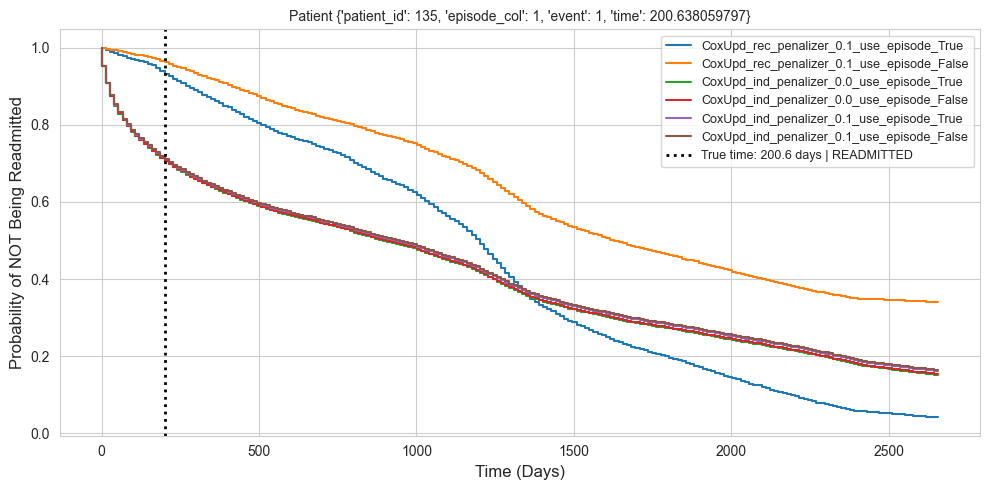

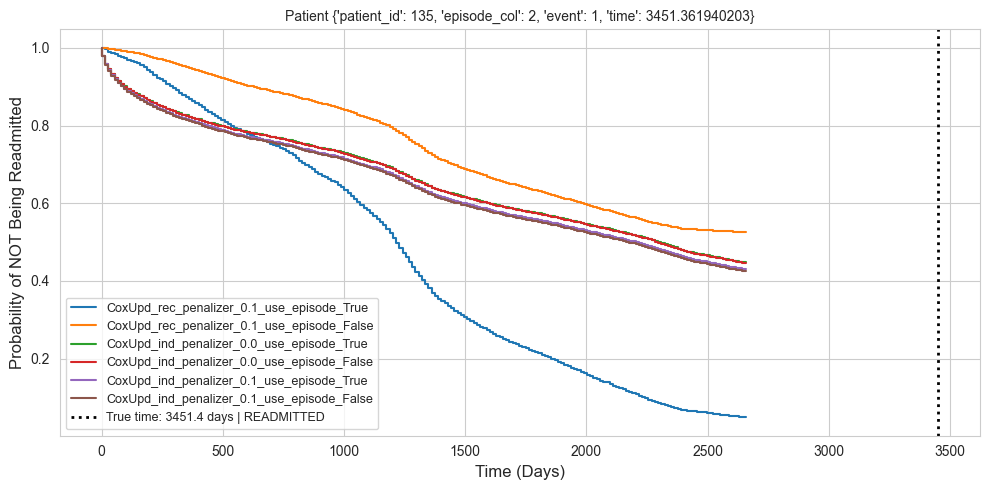

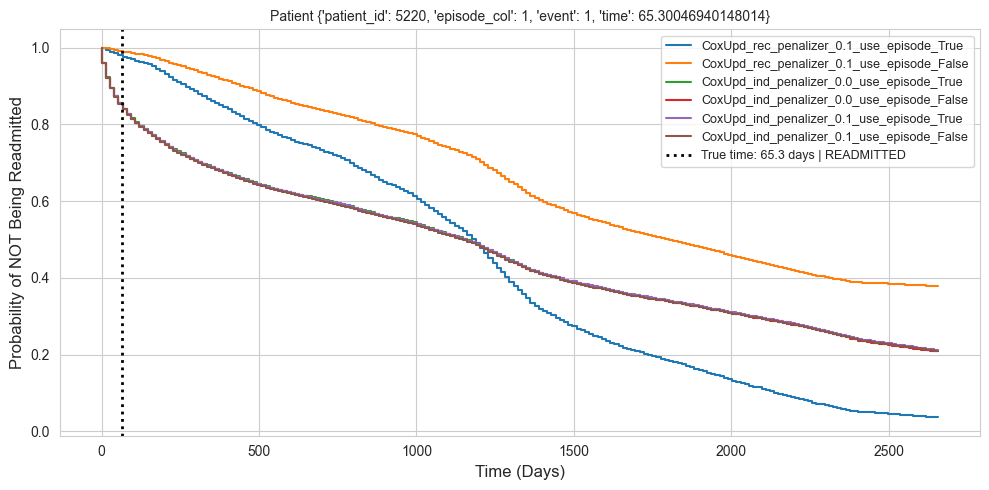

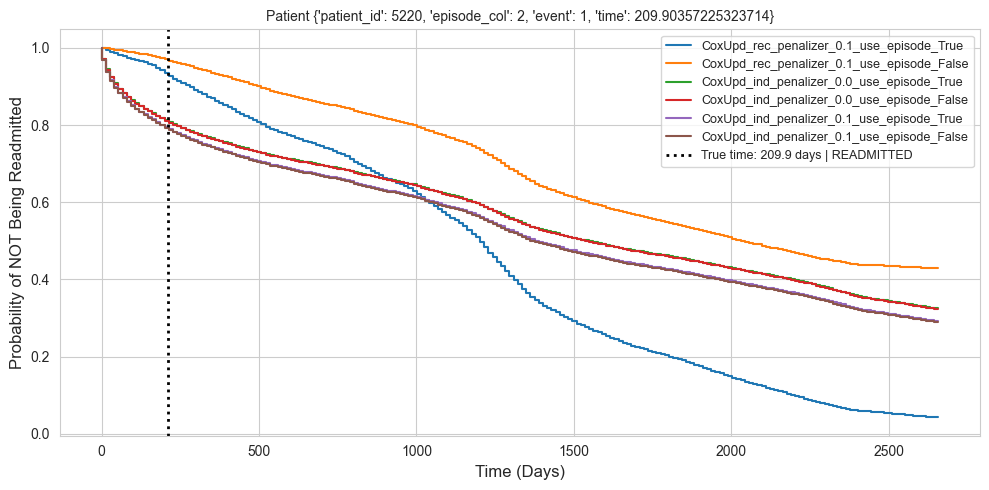

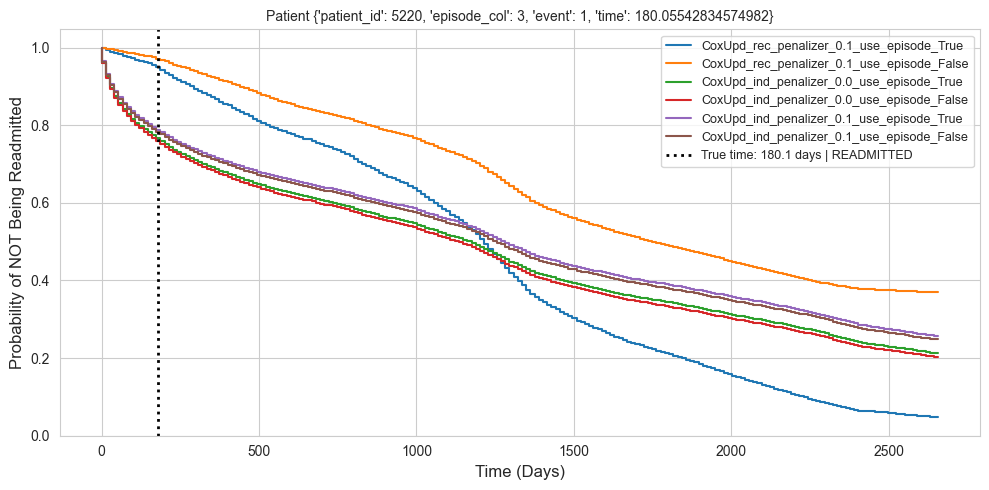

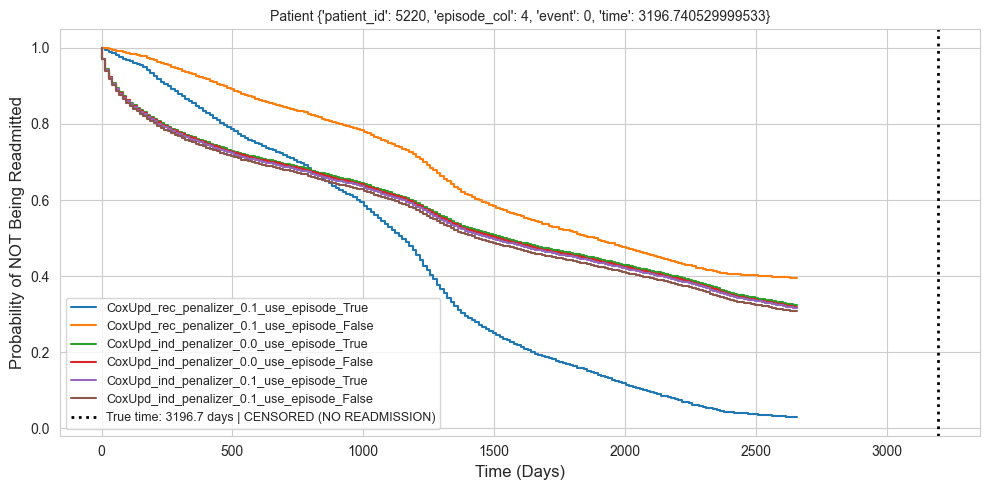

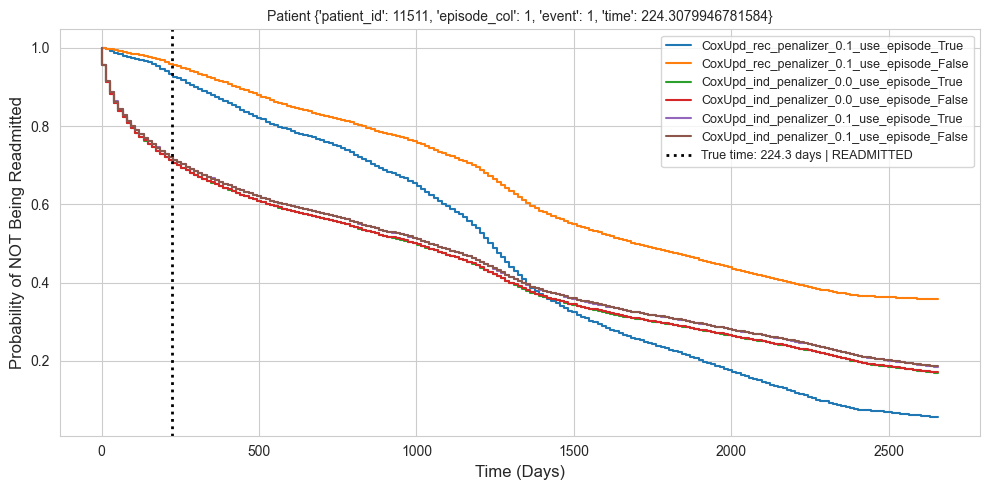

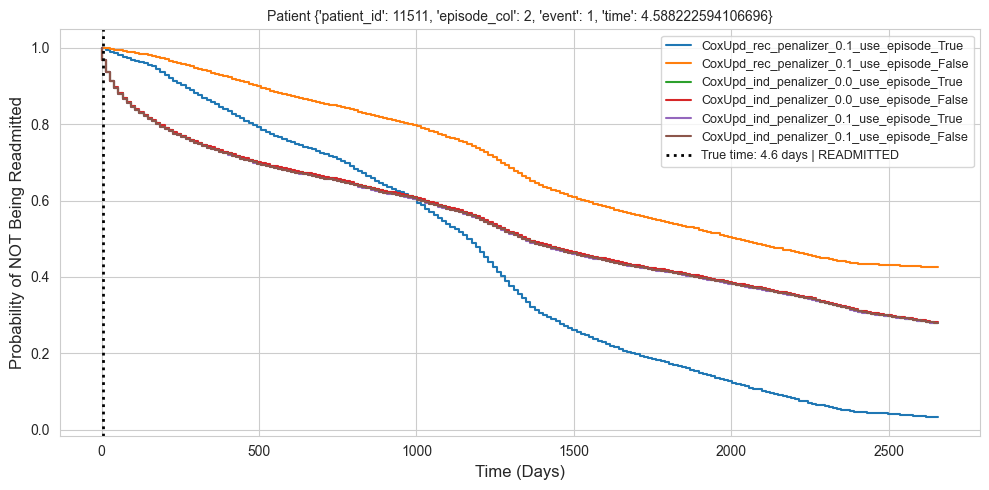

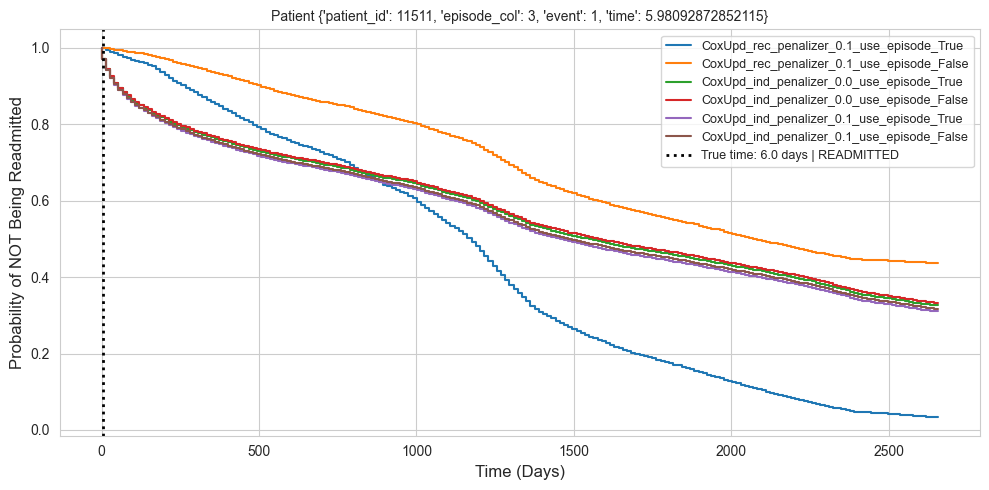

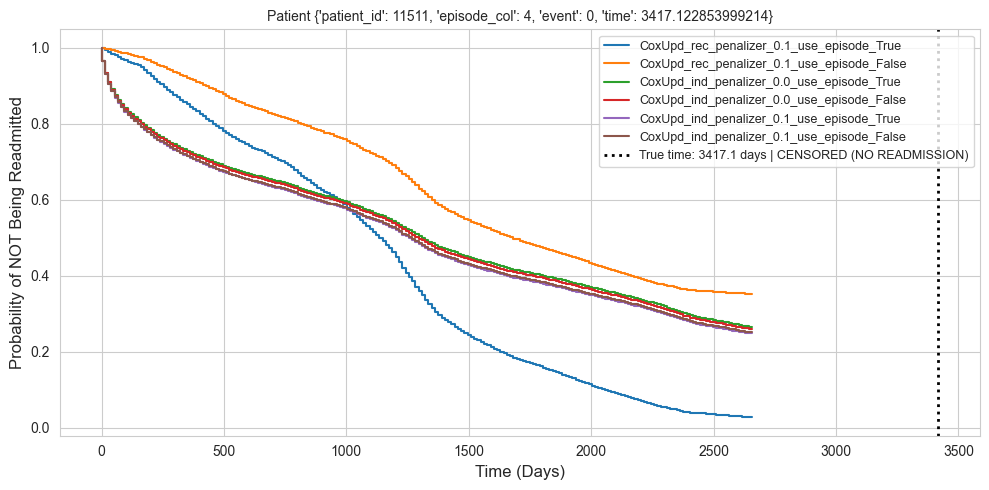

In [24]:
sns.set_style("whitegrid")

# Plot survival curves for 10 test patients
for index_test in range(10):
    plt.figure(figsize=(10, 5))
    
    for name, model in models.items():
        # Predict survival for your diabetes test data
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(
            times, 
            pred.iloc[index_test].values, 
            label=name,
            linewidth=1.5
        )
    
    # Get patient info for the current sample
    sample_info = test_model_df.iloc[index_test]
    
    # True event (readmitted = 1, censored = 0)
    event_status = "READMITTED" if sample_info["event"] == 1 else "CENSORED (NO READMISSION)"
    
    # True time to event (your time column = stop_days / time)
    time_to_event = sample_info["time"]
    
    # Plot vertical line for TRUE TIME
    plt.axvline(
        x=time_to_event,
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"True time: {time_to_event:.1f} days | {event_status}"
    )

    # --------------------------
    # AXES LABELS (DIABETES DATA)
    # --------------------------
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Being Readmitted", fontsize=12)
    
    # --------------------------
    # TITLE (PATIENT INFO)
    # Uses YOUR columns: patient_id, episode_col, event, time
    # --------------------------
    patient_data = test_model_df.iloc[index_test][['patient_id', 'episode_col', 'event', 'time']].to_dict()
    plt.title(f"Patient {patient_data}", fontsize=10)
    
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [25]:
train_model_df = train_model_df.drop(columns=[col for col in cox_df.columns if any(
    s in col for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"])
])
test_model_df = test_model_df.drop(columns=[col for col in cox_df.columns if any(
    s in col for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"])
])
features = [f for f in features if not any(
    s in f for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"]
)]

In [26]:
# train_model_df = train_model_df.drop(columns=["time_since_last_arrest"])
# test_model_df = test_model_df.drop(columns=["time_since_last_arrest"])

In [27]:
# features = [f for f in features if f != "time_since_last_arrest"]
# features_model = [f for f in features_model if f != "time_since_last_arrest"]

In [28]:
train_model_df.info()
test_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37494 entries, 0 to 37493
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 37494 non-null  int64  
 1   start                      37494 non-null  float64
 2   stop                       37494 non-null  float64
 3   event                      37494 non-null  int64  
 4   time                       37494 non-null  float64
 5   episode_col                37494 non-null  int64  
 6   gender                     37494 non-null  int64  
 7   admission_type_id          37494 non-null  int64  
 8   discharge_disposition_id   37494 non-null  int64  
 9   admission_source_id        37494 non-null  int64  
 10  num_lab_procedures         37494 non-null  int64  
 11  num_procedures             37494 non-null  int64  
 12  num_medications            37494 non-null  int64  
 13  number_outpatient          37494 non-null  int

In [29]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}}
    #"RSF_ind": {'model': RSFModel, 'mode': 'independent',
    #            'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "patient_id", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.1_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'patient_id'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,37494


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'patient_id'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,37494
number of events observed,27751


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.0_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 37494 total observations, 9743 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 37494
number of events observed = 27751
   partial log-likelihood = -273792.48
         time fit was run = 2026-05-03 06:35:40 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
episode_col               0.00      1.00      0.00           -0.01            0.01                0.99                1.01
gender                    0.01      1.01      0.01           -0.01            0.04                0.99                1.04
admission_type_id         0.01      1.01      0.00           -0.00            0.02                1.00                1.02
discharge_disposition_id -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
admission_source_id      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_lab_procedures       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_procedures           -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
num_medications           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_outpatient         0.01      1.01      0.00            0.01            0.02                1.01                1.02
number_emergency          0.03      1.04      0.00            0.03            0.04                1.03                1.04
number_inpatient          0.02      1.02      0.00            0.01            0.03                1.01                1.03
number_diagnoses         -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
age_[10-20)               0.00      1.00      0.08           -0.15            0.16                0.86                1.17
age_[20-30)               0.21      1.24      0.05            0.12            0.30                1.13                1.35
age_[30-40)               0.10      1.10      0.03            0.03            0.17                1.03                1.18
age_[40-50)               0.08      1.09      0.03            0.03            0.13                1.03                1.14
age_[50-60)               0.02      1.02      0.02           -0.02            0.06                0.98                1.06
age_[60-70)               0.01      1.01      0.02           -0.03            0.05                0.97                1.05
age_[70-80)              -0.03      0.97      0.02           -0.07            0.01                0.93                1.01
age_[80-90)              -0.05      0.95      0.02           -0.10           -0.01                0.91                0.99
age_[90-100)             -0.13      0.88      0.04           -0.20           -0.05                0.82                0.95
race_AFRICANAMERICAN      0.02      1.02      0.03           -0.03            0.07                0.97                1.07
race_ASIAN               -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
race_CAUCASIAN            0.03      1.03      0.02           -0.02            0.08                0.98                1.08
race_HISPANIC             0.01      1.01      0.05           -0.08            0.10                0.92                1.11
race_OTHER               -0.00      1.00      0.06           -0.11            0.11                0.89                1.11
diabetesMed_Yes           0.05      1.05      0.02            0.02            0.08                1.02                1.09
in

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 37494 total observations, 9743 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 37494
number of events observed = 27751
   partial log-likelihood = -273792.57
         time fit was run = 2026-05-03 06:35:44 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
gender                    0.01      1.01      0.01           -0.01            0.04                0.99                1.04
admission_type_id         0.01      1.01      0.00           -0.00            0.02                1.00                1.02
discharge_disposition_id -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
admission_source_id      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_lab_procedures       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
num_procedures           -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
num_medications           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
number_outpatient         0.01      1.01      0.00            0.01            0.02                1.01                1.02
number_emergency          0.04      1.04      0.00            0.03            0.04                1.03                1.04
number_inpatient          0.02      1.02      0.00            0.01            0.03                1.01                1.03
number_diagnoses         -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
age_[10-20)               0.00      1.00      0.08           -0.15            0.16                0.86                1.17
age_[20-30)               0.21      1.24      0.05            0.12            0.30                1.13                1.35
age_[30-40)               0.10      1.10      0.03            0.03            0.17                1.03                1.18
age_[40-50)               0.08      1.09      0.03            0.03            0.13                1.03                1.14
age_[50-60)               0.02      1.02      0.02           -0.02            0.06                0.98                1.06
age_[60-70)               0.01      1.01      0.02           -0.03            0.05                0.97                1.05
age_[70-80)              -0.03      0.97      0.02           -0.07            0.01                0.93                1.01
age_[80-90)              -0.05      0.95      0.02           -0.10           -0.01                0.91                0.99
age_[90-100)             -0.13      0.88      0.04           -0.20           -0.05                0.82                0.95
race_AFRICANAMERICAN      0.02      1.02      0.03           -0.03            0.07                0.97                1.07
race_ASIAN               -0.06      0.94      0.09           -0.23            0.11                0.79                1.12
race_CAUCASIAN            0.03      1.03      0.02           -0.02            0.08                0.99                1.08
race_HISPANIC             0.01      1.01      0.05           -0.08            0.10                0.92                1.11
race_OTHER               -0.00      1.00      0.06           -0.11            0.11                0.89                1.11
diabetesMed_Yes           0.05      1.05      0.02            0.02            0.08                1.02                1.09
insulin_No               -0.03      0.97      0.02           -0.07            0.00                0.93                1.00
in

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [30]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2858,0.3305,0.5342,0.9250,0.8485,0.6825
1,CoxUpd_rec_penalizer_0.1_use_episode_False,0.2507,0.3475,0.5406,0.9974,0.8970,0.4579
2,CoxUpd_ind_penalizer_0.0_use_episode_True,0.2112,0.3100,0.5402,0.9976,0.9536,0.4925
3,CoxUpd_ind_penalizer_0.0_use_episode_False,0.2111,0.3100,0.5402,0.9976,0.9539,0.4930
4,CoxUpd_ind_penalizer_0.1_use_episode_True,0.2111,0.3099,0.5401,0.9976,0.9567,0.4937
5,CoxUpd_ind_penalizer_0.1_use_episode_False,0.2111,0.3100,0.5401,0.9976,0.9565,0.4934


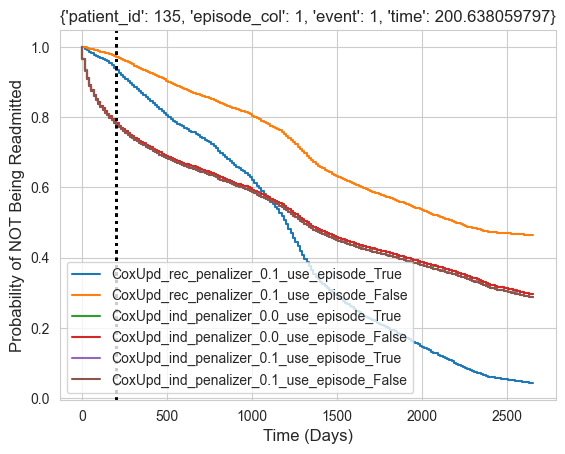

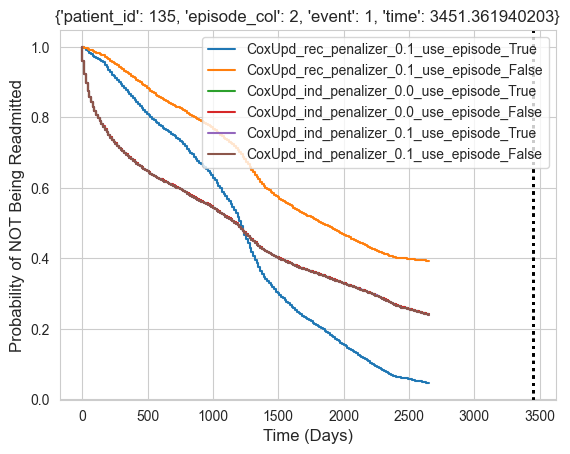

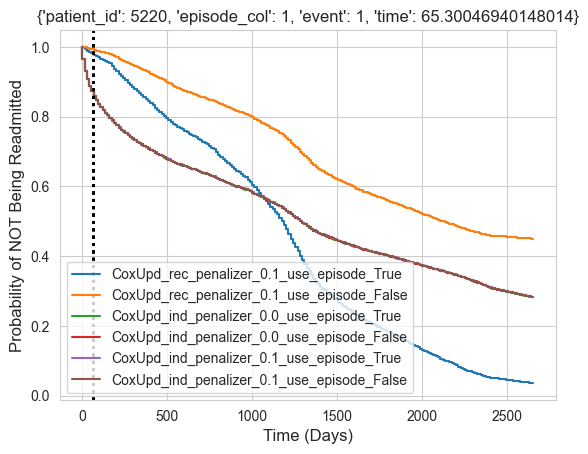

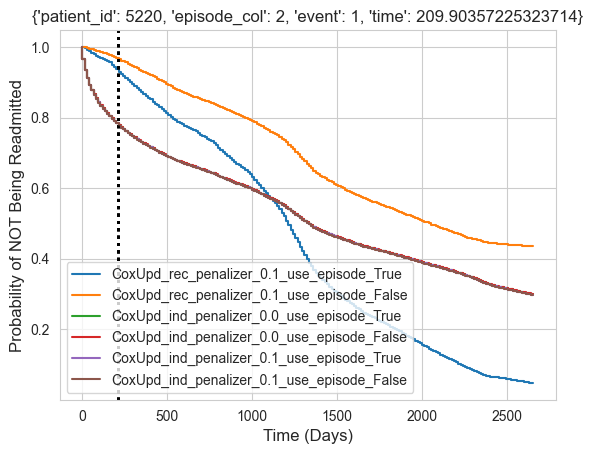

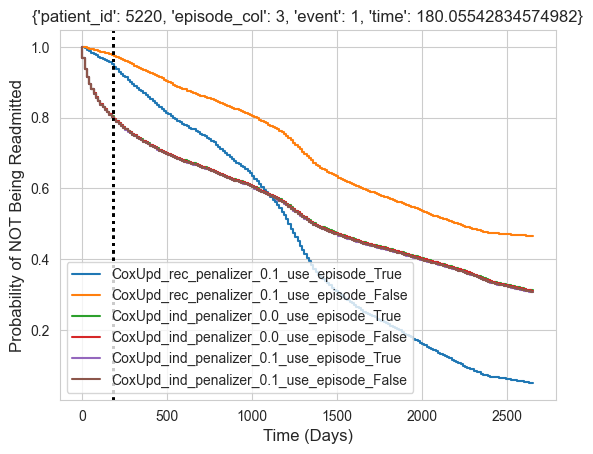

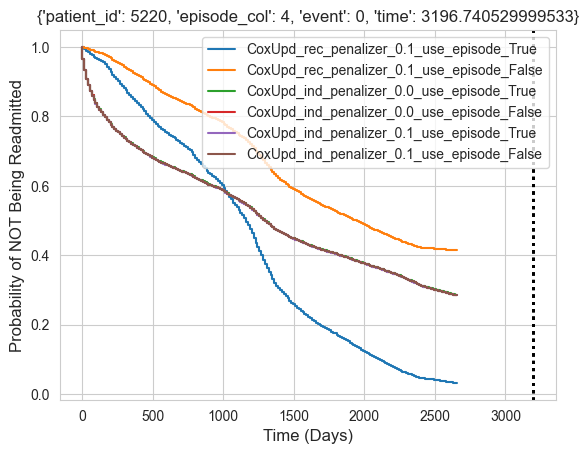

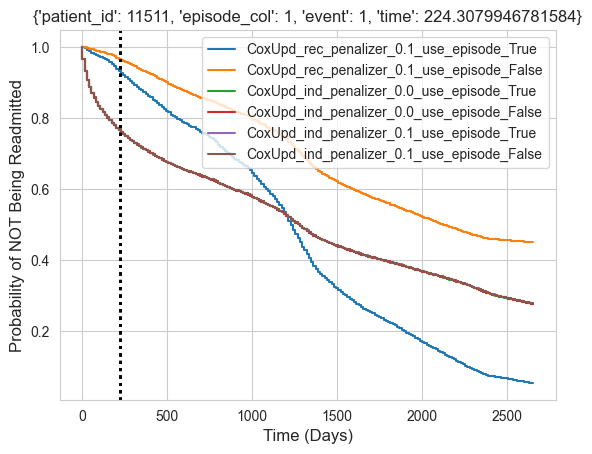

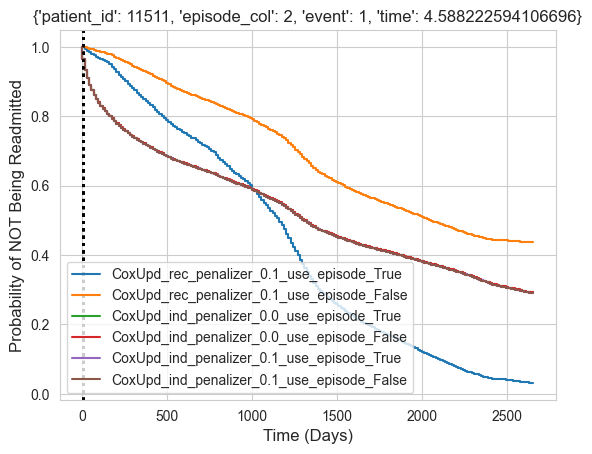

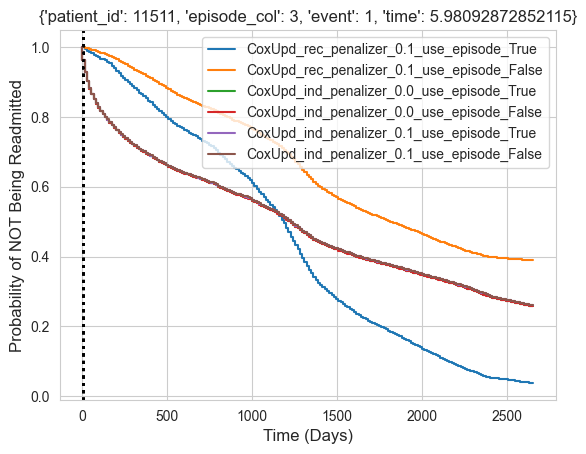

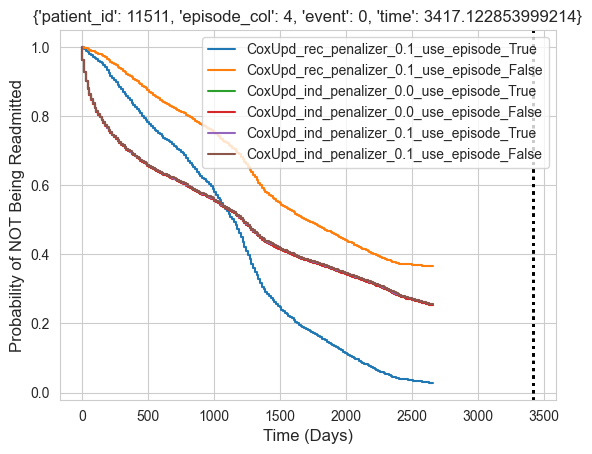

In [31]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        
        # Patient data for diabetes dataset
        sample_info = test_model_df.iloc[index_test]
        event_status = "READMITTED" if sample_info["event"] == 1 else "CENSORED"
        time_to_event = sample_info["time"]  # OR use sample_info["stop_days"] if needed
        
        # Vertical line for true time
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )

    # Axis labels for READMISSION (not recidivism)
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Being Readmitted", fontsize=12)
    
    # Title uses YOUR columns: patient_id (not name)
    plt.title(f"{test_model_df.iloc[index_test][['patient_id', 'episode_col', 'event', 'time']].to_dict()}")
    
    plt.legend()
    plt.show()